Initial Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

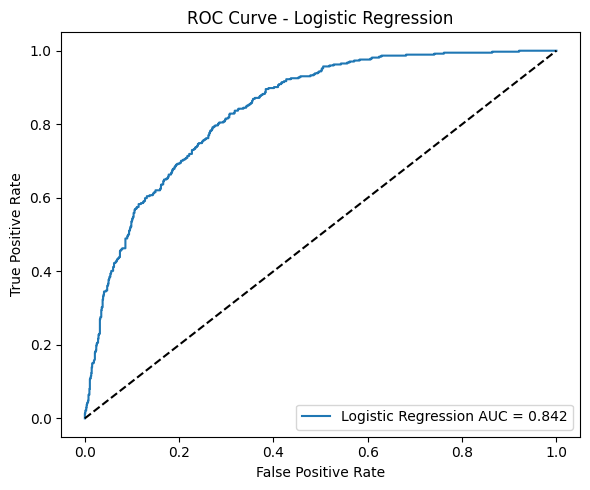


================ CV - LOGISTIC REGRESSION ================
ROC-AUC CV Scores: [0.85826035 0.85850061 0.83315637 0.83831578 0.83894641]
Mean ROC-AUC     : 0.8454359052385275

================ RANDOM FOREST ================
Accuracy : 0.794180269694819
Precision: 0.6372549019607843
Recall   : 0.5213903743315508
F1 Score : 0.5735294117647058
ROC-AUC  : 0.8261334573355035

Confusion Matrix:
[[924 111]
 [179 195]]

================ CV - RANDOM FOREST ================
ROC-AUC CV Scores: [0.83902322 0.83999716 0.80603865 0.81848441 0.82341046]
Mean ROC-AUC     : 0.8253907808932623

Top 10 RF Feature Importances:
                           feature  importance
3                     TotalCharges    0.192975
1                           tenure    0.171350
2                   MonthlyCharges    0.167792
28  PaymentMethod_Electronic check    0.038225
10     InternetService_Fiber optic    0.037704
25               Contract_Two year    0.030909
4                      gender_Male    0.028702
13        

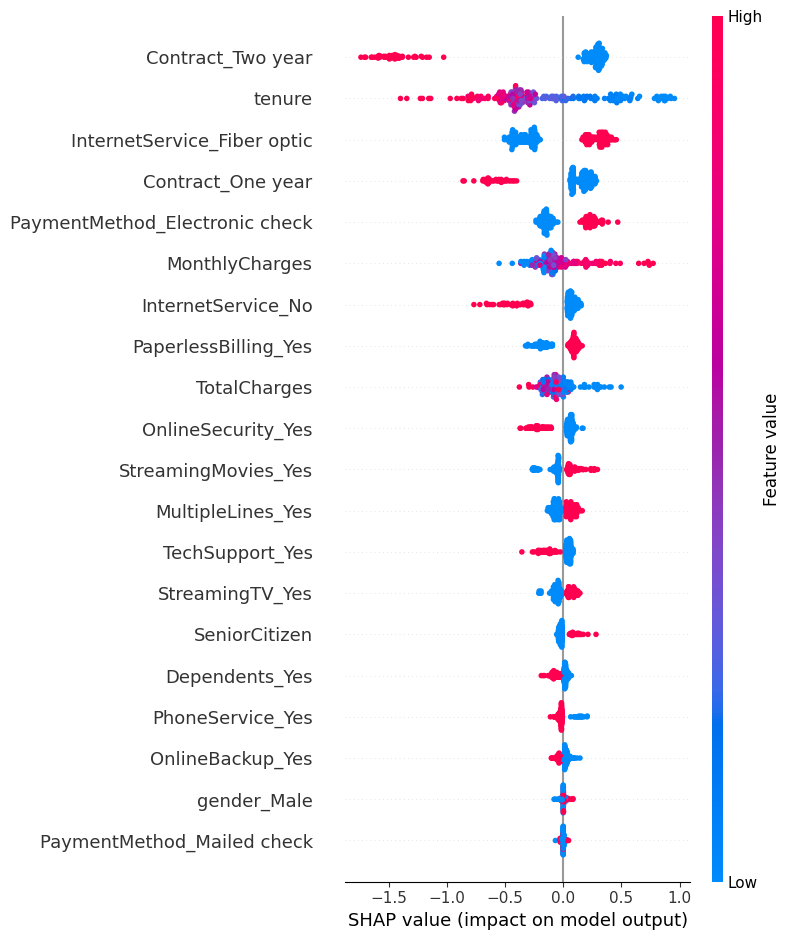


SHAP summary plot saved as shap_summary.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from xgboost import XGBClassifier

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Initial Shape:", df.shape)
print(df.head())

# =========================================================
# 2. CLEAN DATA
# =========================================================
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df = df.fillna(df.mode().iloc[0])

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-hot encode categorical features
categorical_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# =========================================================
# 3. FEATURES AND TARGET
# =========================================================
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# =========================================================
# 5. LOGISTIC REGRESSION
# =========================================================
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("\n================ LOGISTIC REGRESSION ================")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# =========================================================
# 6. THRESHOLD TUNING (LOGISTIC REGRESSION)
# =========================================================
thresholds = [0.5, 0.4, 0.3, 0.2]

print("\n================ THRESHOLD TUNING ================")
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_log >= t).astype(int)

    acc = accuracy_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    cm = confusion_matrix(y_test, y_pred_t)

    threshold_results.append({
        "Threshold": t,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print(f"\nThreshold: {t}")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Confusion Matrix:")
    print(cm)

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold comparison:")
print(threshold_df)

best_threshold_row = threshold_df.sort_values("F1", ascending=False).iloc[0]
best_threshold = best_threshold_row["Threshold"]

print("\nBest threshold based on F1:", best_threshold)

# =========================================================
# 7. ROC CURVE + AUC (LOGISTIC REGRESSION)
# =========================================================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_log)
auc_score_log = roc_auc_score(y_test, y_prob_log)

print("\n================ ROC / AUC (LOGISTIC) ================")
print("AUC Score:", auc_score_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc_score_log:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_logistic.png")
plt.show()

# =========================================================
# 8. CROSS VALIDATION - LOGISTIC REGRESSION
# =========================================================
log_cv_scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("\n================ CV - LOGISTIC REGRESSION ================")
print("ROC-AUC CV Scores:", log_cv_scores)
print("Mean ROC-AUC     :", log_cv_scores.mean())

# =========================================================
# 9. RANDOM FOREST CLASSIFIER
# =========================================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_score_rf = roc_auc_score(y_test, y_prob_rf)

print("\n================ RANDOM FOREST ================")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", auc_score_rf)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Cross validation for RF
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("\n================ CV - RANDOM FOREST ================")
print("ROC-AUC CV Scores:", rf_cv_scores)
print("Mean ROC-AUC     :", rf_cv_scores.mean())

# Feature importance
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 RF Feature Importances:")
print(rf_importance.head(10))

# =========================================================
# 10. XGBOOST CLASSIFIER
# =========================================================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_score_xgb = roc_auc_score(y_test, y_prob_xgb)

print("\n================ XGBOOST ================")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", auc_score_xgb)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

# Cross validation for XGB
xgb_cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ),
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("\n================ CV - XGBOOST ================")
print("ROC-AUC CV Scores:", xgb_cv_scores)
print("Mean ROC-AUC     :", xgb_cv_scores.mean())

# =========================================================
# 11. GRID SEARCH - RANDOM FOREST
# =========================================================
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]
best_rf_pred = best_rf.predict(X_test)

best_rf_auc = roc_auc_score(y_test, best_rf_prob)

print("\n================ BEST RANDOM FOREST (GRID SEARCH) ================")
print("Best Params:", grid_rf.best_params_)
print("Best ROC-AUC:", best_rf_auc)
print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1 Score :", f1_score(y_test, best_rf_pred))

# =========================================================
# 12. GRID SEARCH - XGBOOST
# =========================================================
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid_xgb,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
best_xgb_prob = best_xgb.predict_proba(X_test)[:, 1]
best_xgb_pred = best_xgb.predict(X_test)

best_xgb_auc = roc_auc_score(y_test, best_xgb_prob)

print("\n================ BEST XGBOOST (GRID SEARCH) ================")
print("Best Params:", grid_xgb.best_params_)
print("Best ROC-AUC:", best_xgb_auc)
print("Accuracy :", accuracy_score(y_test, best_xgb_pred))
print("Precision:", precision_score(y_test, best_xgb_pred))
print("Recall   :", recall_score(y_test, best_xgb_pred))
print("F1 Score :", f1_score(y_test, best_xgb_pred))

# =========================================================
# 13. MODEL COMPARISON TABLE
# =========================================================
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Best Random Forest (Grid)",
        "Best XGBoost (Grid)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, best_rf_pred),
        accuracy_score(y_test, best_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, best_rf_pred),
        precision_score(y_test, best_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, best_rf_pred),
        recall_score(y_test, best_xgb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, best_rf_pred),
        f1_score(y_test, best_xgb_pred)
    ],
    "ROC_AUC": [
        auc_score_log,
        auc_score_rf,
        auc_score_xgb,
        best_rf_auc,
        best_xgb_auc
    ]
})

results = results.sort_values("ROC_AUC", ascending=False)
print("\n================ MODEL COMPARISON ================")
print(results)

# =========================================================
# 14. CHOOSE BEST MODEL AUTOMATICALLY
# =========================================================
best_model_name = results.iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    final_model = log_model
elif best_model_name == "Random Forest":
    final_model = rf_model
elif best_model_name == "XGBoost":
    final_model = xgb_model
elif best_model_name == "Best Random Forest (Grid)":
    final_model = best_rf
else:
    final_model = best_xgb

print("\nBest model selected automatically:", best_model_name)

# =========================================================
# 15. SAVE BEST MODEL
# =========================================================
joblib.dump(final_model, "best_churn_model.pkl")
joblib.dump(list(X.columns), "churn_model_features.pkl")

print("\nSaved files:")
print("1. best_churn_model.pkl")
print("2. churn_model_features.pkl")

# =========================================================
# 16. SHAP ANALYSIS (for tree-based final model if applicable)
# =========================================================
if best_model_name in ["Random Forest", "XGBoost", "Best Random Forest (Grid)", "Best XGBoost (Grid)"]:
    X_sample = X_test.sample(min(200, len(X_test)), random_state=42)

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_sample)

    # For binary classification, some versions return list, some array
    if isinstance(shap_values, list):
        shap_plot_values = shap_values[1]
    else:
        shap_plot_values = shap_values

    plt.figure()
    shap.summary_plot(shap_plot_values, X_sample, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary.png", bbox_inches="tight")
    plt.show()

    print("\nSHAP summary plot saved as shap_summary.png")
else:
    print("\nFinal model is Logistic Regression, so SHAP tree plot skipped.")

In [3]:
from google.colab import files

files.download("best_churn_model.pkl")
files.download("churn_model_features.pkl")
files.download("roc_curve_logistic.png")

# If SHAP file exists
try:
    files.download("shap_summary.png")
except:
    print("SHAP file not available for the selected final model.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>